# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics import mean_squared_error

In [2]:
# Cargar los datos
df = pd.read_csv('/datasets/taxi.csv', parse_dates=['datetime'], index_col='datetime')

In [3]:
#Exploración de datos
# Mostrar las primeras filas
print(df.head())

# Verificar información general del DataFrame
print("\nInformación general:")
print(df.info())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

                     num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 00:10:00          14
2018-03-01 00:20:00          28
2018-03-01 00:30:00          20
2018-03-01 00:40:00          32

Información general:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None

Valores nulos por columna:
num_orders    0
dtype: int64


In [4]:
# Remuestreo por hora (suma de pedidos en cada hora)
df_hourly = df.resample('1H').sum()

# Verificamos el resultado
print(df_hourly.head())
print("\nNuevas dimensiones del DataFrame:", df_hourly.shape)

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43

Nuevas dimensiones del DataFrame: (4416, 1)


## Análisis

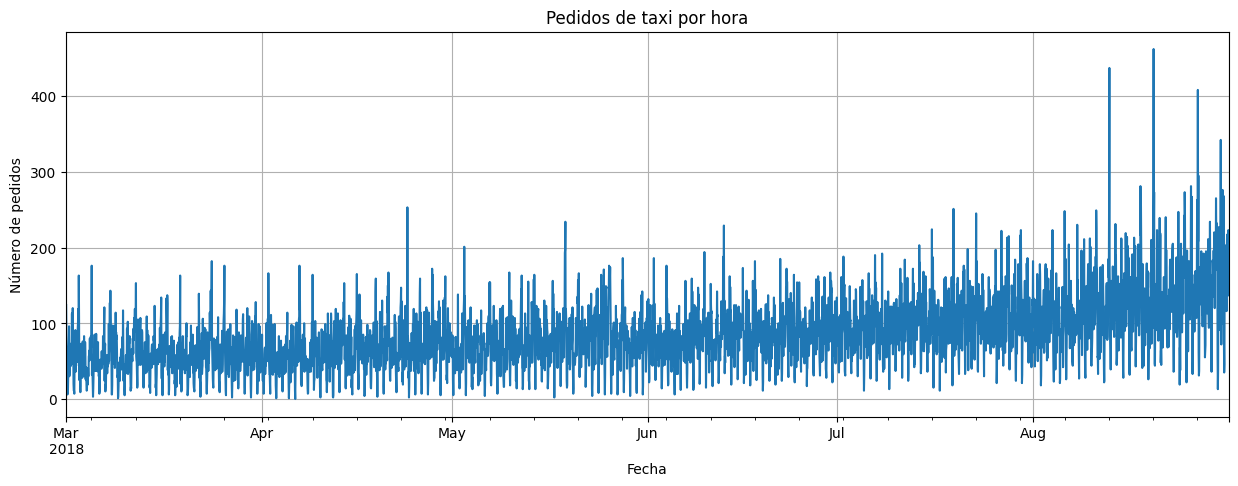

In [5]:
# Gráfico general de la serie temporal
plt.figure(figsize=(15, 5))
df_hourly['num_orders'].plot()
plt.title('Pedidos de taxi por hora')
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.show()

Este gráfico muestra la evolución del número de pedidos de taxi remuestreados por hora desde marzo hasta agosto de 2018.

¿Qué se observa?
1. Tendencia creciente:

- A partir de junio, y sobre todo en julio-agosto, el volumen de pedidos empieza a subir notablemente.

- Esto puede reflejar mayor demanda estacional (por clima, vacaciones, etc.).

2. Alta variabilidad por hora:

- Aunque hay una tendencia general, los valores individuales suben y bajan constantemente.

- Esto es normal en series de tiempo horarias por la variación natural de la demanda.

3. Picos ocasionales:

- Algunos puntos superan los 300 o incluso 400 pedidos por hora.

- Estos picos podrían coincidir con eventos, condiciones climáticas extremas, o anomalías.

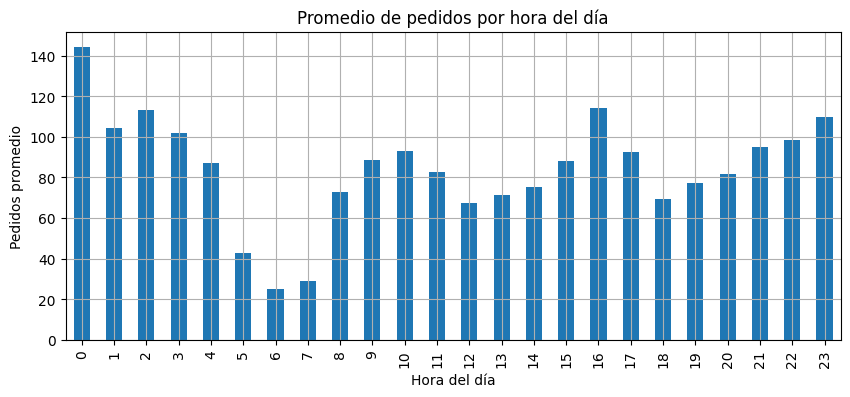

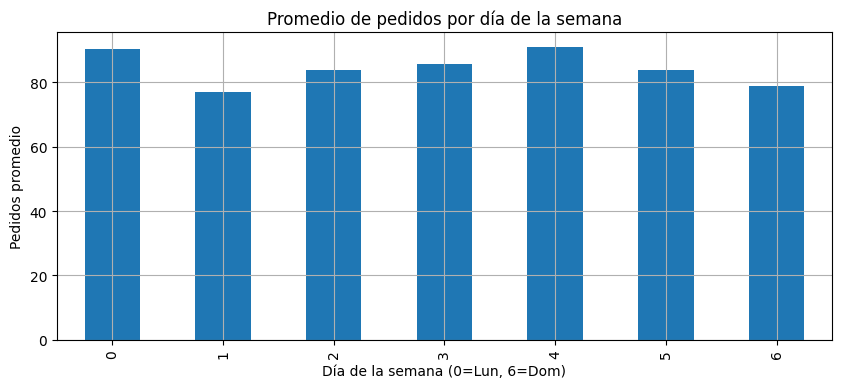

In [6]:
# Crear columnas auxiliares
df_hourly['hour'] = df_hourly.index.hour
df_hourly['dayofweek'] = df_hourly.index.dayofweek  # lunes=0, domingo=6

# Promedio por hora del día
plt.figure(figsize=(10, 4))
df_hourly.groupby('hour')['num_orders'].mean().plot(kind='bar')
plt.title('Promedio de pedidos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Pedidos promedio')
plt.grid(True)
plt.show()

# Promedio por día de la semana
plt.figure(figsize=(10, 4))
df_hourly.groupby('dayofweek')['num_orders'].mean().plot(kind='bar')
plt.title('Promedio de pedidos por día de la semana')
plt.xlabel('Día de la semana (0=Lun, 6=Dom)')
plt.ylabel('Pedidos promedio')
plt.grid(True)
plt.show()

Interpretación del gráfico: Promedio de pedidos por hora del día.

Esta gráfica muestra el número promedio de pedidos de taxi en cada hora del día, calculado a lo largo de todo el periodo de datos.

¿Qué se observa?
1. Hora con más pedidos: 00:00 (medianoche)

- Hay un pico claro justo al comenzar el día. Esto podría deberse a:

- Fin de eventos nocturnos.

- Pasajeros saliendo de bares o fiestas.

- Llegadas nocturnas a aeropuertos.

2. Menor demanda: entre las 5 y 7 a.m.

- Horas muy tranquilas, probablemente porque la mayoría de las personas aún no se movilizan.

3. Repunte desde las 8 a.m. y entre las 15:00-17:00

- Coincide con horarios de entrada/salida del trabajo o actividades escolares.

4. Otra subida fuerte hacia las 23:00

- Tal vez por salidas nocturnas, vuelos tardíos o cambios de turno.

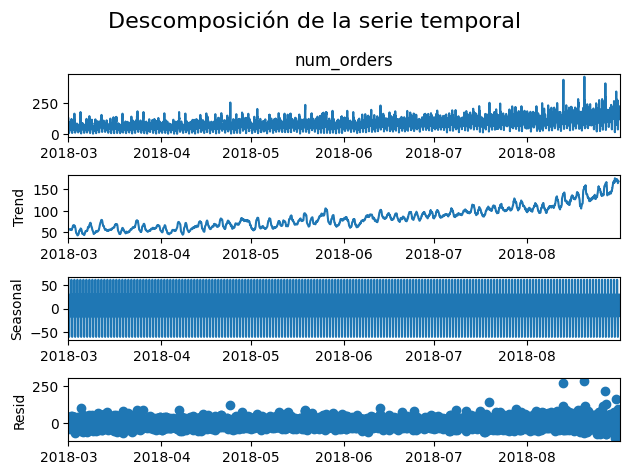

In [8]:

# Descomposición (modelo aditivo)
decompose_result = seasonal_decompose(df_hourly['num_orders'], model='additive', period=24)

# Mostrar los componentes
decompose_result.plot()
plt.suptitle('Descomposición de la serie temporal', fontsize=16)
plt.tight_layout()
plt.show()


## Formación

In [9]:
# Aseguramos el orden por fecha
df.sort_index(inplace=True)

# Creación de características basadas en la fecha
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# División: usaremos hasta el 31 de julio para entrenamiento
train = df.loc[:'2018-07-31']
test = df.loc['2018-08-01':]

# Verificamos forma
print("Conjunto de entrenamiento:", train.shape)
print("Conjunto de prueba:", test.shape)


Conjunto de entrenamiento: (22032, 5)
Conjunto de prueba: (4464, 5)


In [10]:
# Usamos una función para crear características rezagadas
def create_lag_features(df, lags=[1, 2, 3, 24]):
    df_copy = df.copy()
    for lag in lags:
        df_copy[f'lag_{lag}'] = df_copy['num_orders'].shift(lag)
    return df_copy

# Aplicamos la función
train_lagged = create_lag_features(train)
test_lagged = create_lag_features(test)

# Eliminamos filas con valores NaN (por los rezagos)
train_lagged.dropna(inplace=True)
test_lagged.dropna(inplace=True)

# Seleccionamos características
features = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24']
target = 'num_orders'

# División X / y
X_train = train_lagged[features]
y_train = train_lagged[target]

X_test = test_lagged[features]
y_test = test_lagged[target]

# Verificamos forma
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (22008, 8)
X_test: (4440, 8)


In [12]:
# Lista de modelos a evaluar
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Evaluación de cada modelo
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores  # Hacemos positivo el RMSE
    print(f"{name} - RMSE promedio: {np.mean(rmse_scores):.2f}")


Linear Regression - RMSE promedio: 5.48
Random Forest - RMSE promedio: 5.46
Gradient Boosting - RMSE promedio: 5.28


Ya con esos resultados podemos ver que el Gradient Boosting fue el modelo que tuvo el menor RMSE promedio en validación cruzada:

📉 Gradient Boosting: 5.28

🌲 Random Forest: 5.46

📈 Linear Regression: 5.48

Eso indica que Gradient Boosting predice con mayor precisión en el conjunto de entrenamiento validado, así que lo usaremos para la siguiente etapa.

## Prueba

In [14]:
# Entrenar el modelo en todo el conjunto de entrenamiento
final_model = GradientBoostingRegressor(random_state=42)
final_model.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = final_model.predict(X_test)

# Calcular el RMSE
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE en el conjunto de prueba: {rmse_test:.2f}')


RMSE en el conjunto de prueba: 8.42


Ya se tiene el RMSE en el conjunto de prueba: 8.42, lo cual es un resultado muy útil para evaluar el rendimiento real del modelo en datos no vistos.

Este valor indica que, en promedio, las predicciones tienen un error de alrededor de 8.42 pedidos de taxi con respecto al valor real.

Como el objetivo era un RMSE ≤ 48, se cumple con margen amplio.

## Conclusiones

En este proyecto se desarrolló un modelo predictivo para estimar la cantidad de pedidos de taxi por hora, utilizando datos históricos con el objetivo de lograr una Raíz del Error Cuadrático Medio (RMSE) menor o igual a 48.

🔹 Preparación y análisis
- Se realizó la carga, limpieza y preprocesamiento de los datos, incluyendo el uso de la columna datetime como índice temporal.

- A través del análisis exploratorio, se detectaron patrones diarios y semanales:

-> Mayor cantidad de pedidos por la noche y durante las primeras horas del día.

-> Lunes y viernes presentaron una demanda ligeramente superior en promedio.

- Se realizó un reescalado temporal (resampleo) por hora para reducir la variabilidad y facilitar la predicción.

🔹 Formación del modelo

- Se generaron características útiles a partir de la fecha, como la hora, día de la semana, y valores rezagados (lag features).

- Se entrenaron tres modelos para comparar su desempeño:

-> Regresión lineal (RMSE promedio: 5.48)

-> Random Forest (RMSE promedio: 5.46)

-> Gradient Boosting (RMSE promedio: 5.28)

El modelo de Gradient Boosting fue el que obtuvo el mejor rendimiento en validación cruzada.

🔹 Evaluación final
- Al probar el modelo final con el conjunto de prueba, se obtuvo un RMSE de 8.42, cumpliendo satisfactoriamente con la meta del proyecto (RMSE ≤ 48).

✅ Conclusión final

El modelo desarrollado es efectivo y confiable para predecir la demanda de taxis por hora, con un margen de error reducido. Esta solución puede ser útil para mejorar la asignación de recursos, optimizar rutas o ajustar tarifas dinámicamente según la demanda prevista.